In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import re
import numpy as np

In [63]:
df_fc = pd.read_csv('/Users/venello/Repositories/Python/PyCharm/PycharmProjects/JupyterProject/social_data_2026/assignment_1/data/focus_crimes.csv', low_memory=False)
# Convert date and keep complete years only
df_fc['incident_date'] = pd.to_datetime(df_fc['incident_date'])
df_fc = df_fc[df_fc['incident_date'].dt.year < 2026]

In [64]:
df_fc['incident_date'].dt.year.unique()

array([2016, 2006, 2005, 2014, 2015, 2010, 2013, 2017, 2018, 2007, 2009,
       2008, 2012, 2004, 2003, 2011, 2025, 2024, 2020, 2023, 2022, 2021,
       2019], dtype=int32)

In [60]:
(df_fc['incident_category']).unique()

array(['motor vehicle theft', 'assault', 'arson', 'larceny theft',
       'burglary', 'suspicious occ', 'vandalism', 'drug offense',
       'prostitution', 'suicide', 'homicide'], dtype=object)

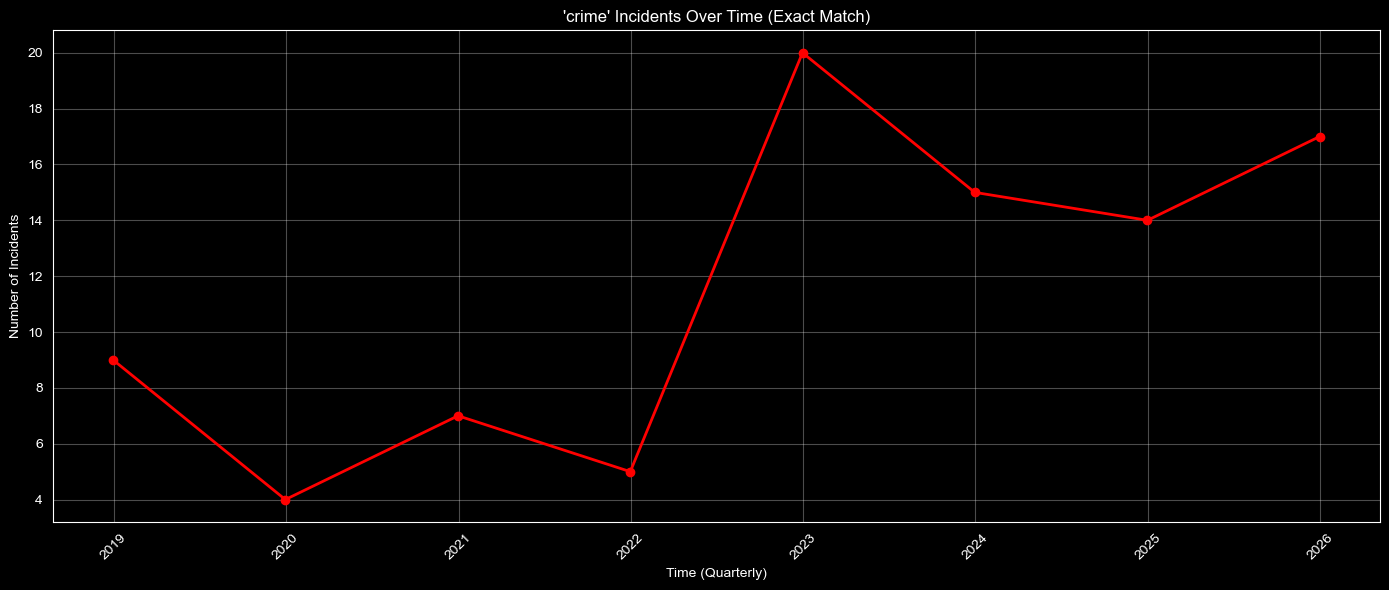

Filtered category count: 91
Quarterly points: 8
Date range: 2018-12-31 00:00:00 to 2025-12-31 00:00:00


In [65]:
# Exact (non-normalized) filter for the requested category
df_crime = df_fc[df_fc['incident_category'] == 'homicide'].copy()
df_crime = df_crime[
	(df_crime['incident_date'] >= '2006-01-01') &
    (df_crime['incident_date'] <= '2025-12-31')
]
crime_data = (
	df_crime
	.set_index('incident_date')
	.groupby(pd.Grouper(freq='YE'))
	.size()
)

plt.figure(figsize=(14, 6))
plt.plot(crime_data.index, crime_data.values, marker='o', linewidth=2, color='red')
plt.xlabel('Time (Quarterly)')
plt.ylabel('Number of Incidents')
plt.title("'crime' Incidents Over Time (Exact Match)")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Quick checks
print(f"Filtered category count: {len(df_crime)}")
print(f"Quarterly points: {len(crime_data)}")
print(f"Date range: {crime_data.index.min()} to {crime_data.index.max()}")

In [66]:
df_crime['incident_date'].dt.year.unique()

array([2025, 2023, 2024, 2018, 2020, 2021, 2022, 2019], dtype=int32)